<a href="https://colab.research.google.com/github/shaniaoracion/CPE-018-CPE31S2/blob/main/Activity_5_Line_and_Circle_Detection_Oracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2026-2027
<hr> | <hr>
<u>**ACTIVITY NO. 4.1** | **Line and Circle Detection**
**Name** | Oracion, Shania Faye, C.
**Section** | CPE31S2
**Date Performed**: | 01/20/26
**Date Submitted**: | 01/20/26
**Instructor**: | Engr. Sayo

<hr>

## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

In [26]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


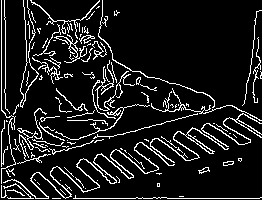

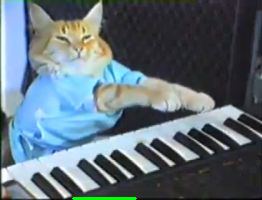

In [16]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat

from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/drive/MyDrive/emtech/keyboard_cat.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,120)
minLineLength = 20
maxLineGap = 5
lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength,
        maxLineGap)
for x1,y1,x2,y2 in lines[0]:
  cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(edges)
cv2_imshow(img)

The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?
  - The line of code responsible for this is the cv2.HoughLinesP function call, specifically using the minLineLength parameter. This parameter ensures that any detected line segments shorter than this specified value are discarded, helping to filter out small noise.
2. What is the mathematical formula for Hough transform and explain how it finds lines.
  - The mathematical formula used for the Hough Transform to represent lines in a polar coordinate system is:$$x \cos(\theta) + y \sin(\theta) = \rho$$

### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

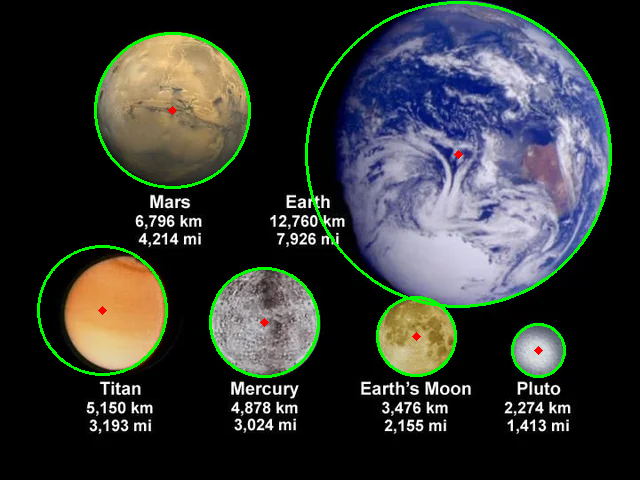

In [25]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

n = 21

planets = cv2.imread('/content/drive/MyDrive/emtech/planets.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100,
                            param1=100, param2=22, minRadius=15,
                            maxRadius=300)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        # Draw green outer circle
        cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
        # Draw red center point
        cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2_imshow(planets)

What happens to the code once you run **and the value of n is 5**?
  - *The image is quite "messy." Because the blur is low, the algorithm detects internal textures on the planets—specifically the clouds on Earth and craters on Mercury—as individual circles. This leads to multiple overlapping green rings on a single planet, as the code is too sensitive to small details.*

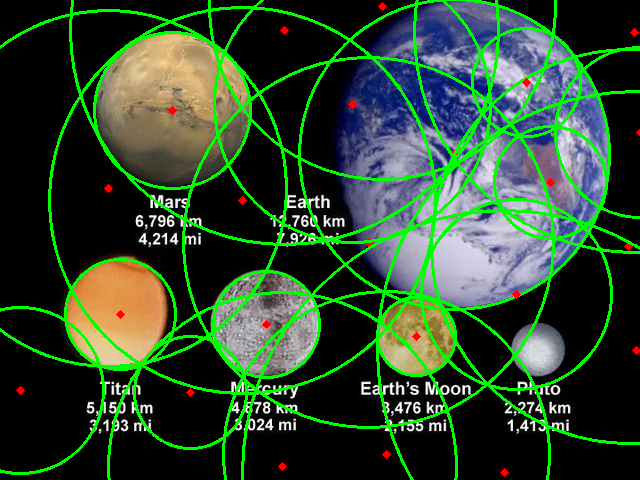

In [22]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

n = 5

planets = cv2.imread('/content/drive/MyDrive/emtech/planets.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100,
                            param1=100, param2=22, minRadius=15,
                            maxRadius=300)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        # Draw green outer circle
        cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
        # Draw red center point
        cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2_imshow(planets)

Change the value to 9, **what happens to the image**?
  - *The image starts to clean up significantly. The increased blur begins to "wash out" the smaller surface details, making the planets look more like solid round objects. While most extra circles disappear, there might still be one or two "phantom" circles on Earth where the cloud contrast is strongest.*

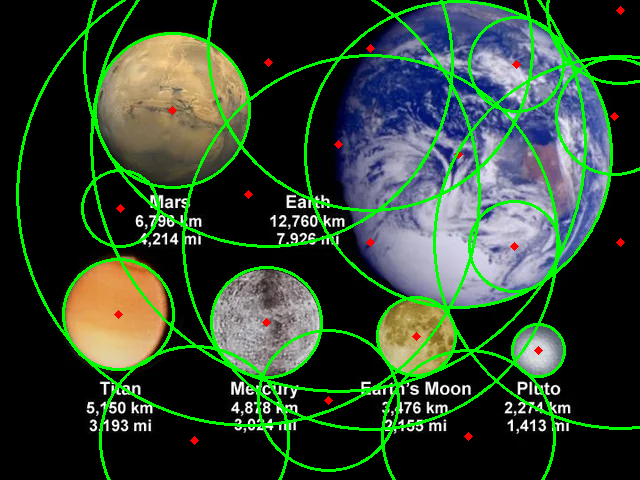

In [23]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

n = 9
planets = cv2.imread('/content/drive/MyDrive/emtech/planets.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100,
                            param1=100, param2=22, minRadius=15,
                            maxRadius=300)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        # Draw green outer circle
        cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
        # Draw red center point
        cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2_imshow(planets)

Lastly, change the value to 15, **what can you say about the resulting image?**
  - *The resulting image is much cleaner and more accurate. At this level, the internal noise and surface textures are almost entirely smoothed away. The algorithm now focuses strictly on the strong outer circular edges of the planets, resulting in a single, well-defined green circle for each major body.*

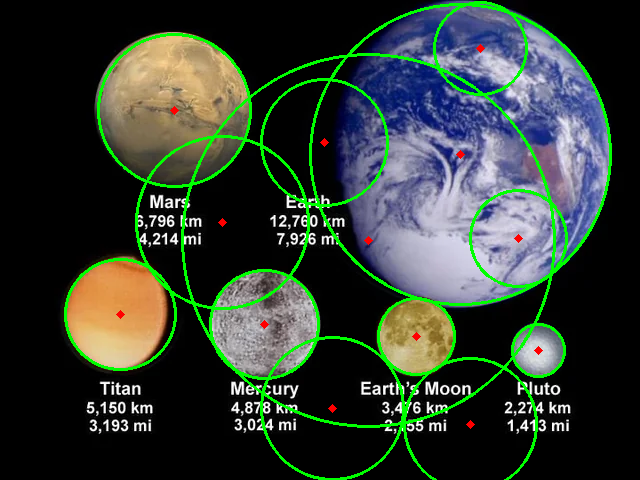

In [24]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

n = 15

planets = cv2.imread('/content/drive/MyDrive/emtech/planets.webp')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n)

circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100,
                            param1=100, param2=22, minRadius=15,
                            maxRadius=300)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        # Draw green outer circle
        cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
        # Draw red center point
        cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2_imshow(planets)

Provide an analysis of the output so far. How does the code help the changes in the resulting image?

Observations : When $n=5$: I observe many "unnecessary" circles inside Earth and Mars. This is because the blur is too light to hide the clouds and surface details, which the computer mistakes for separate circles.When $n=9$: The image becomes cleaner. Most of the internal "noise" circles disappear as the surface textures begin to smooth out, though some errors may remain on high-contrast areas.When $n=15$: The resulting image is the most accurate. The heavy blur has "washed out" all internal details, leaving only the solid round shape of the planets for the algorithm to detect.

Analysis of the Output
  - The code uses cv2.medianBlur as a pre-processing filter to suppress "high-frequency" noise (like the text and craters) while preserving the "low-frequency" edges (the planet's round shape). As I increase the value of $n$, the code effectively simplifies the image, allowing the HoughCircles algorithm to focus only on the actual boundaries of the planets rather than their complex internal textures.

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

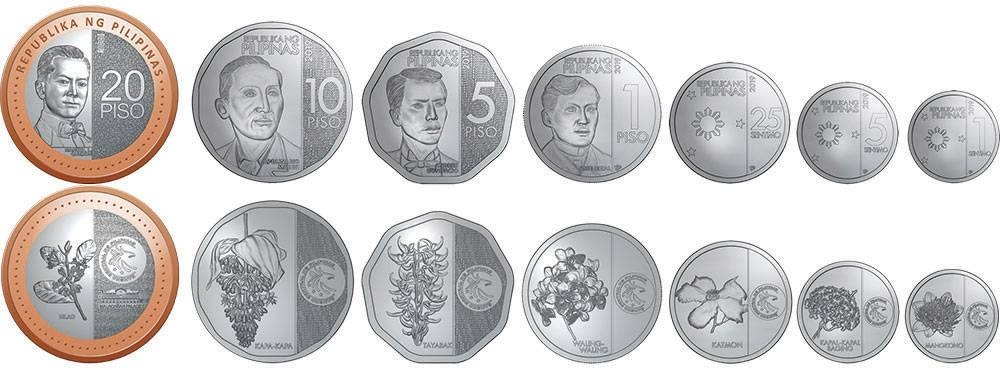

Total coins detected via Circle Detection: 14


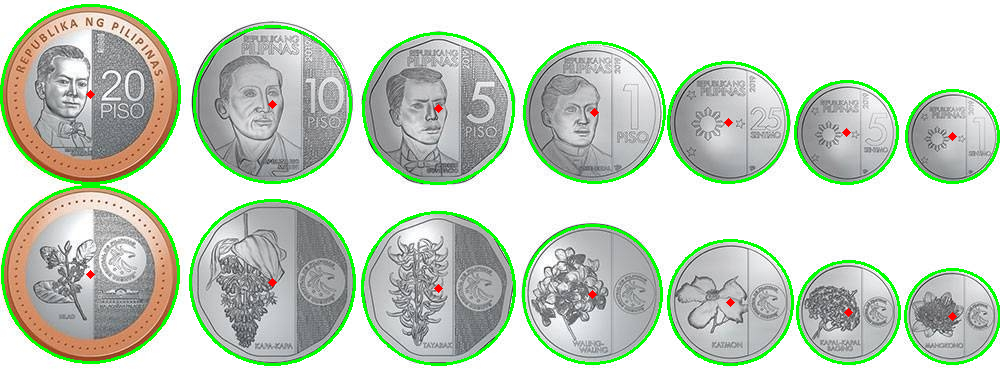

In [18]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def count_coins_circles(image_path):
    # Load and preprocess
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Use a high blur (n=15) to ignore the faces/details on the coins
    blurred = cv2.medianBlur(gray, 15)

    # Detect circles
    # param2=30 is a good balance for these distinct coin shapes
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1, minDist=50,
                               param1=100, param2=30, minRadius=20, maxRadius=150)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        count = len(circles[0])

        for i in circles[0, :]:
            # Draw the circle in green
            cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Draw center in red
            cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)

        print(f"Total coins detected via Circle Detection: {count}")
        cv2_imshow(img)
    else:
        print("No coins detected.")

count_coins_circles('/content/drive/MyDrive/emtech/phcoins.jpg')

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?
    - *The output consists of scattered, disjointed line segments that primarily cling to high-contrast edges of the image or the internal details of the coins, rather than identifying the coins themselves. No. My testing shows that HoughLines is mathematically optimized to find straight paths by looking for collinear points. Because a coin’s edge is continuously curved with no straight segments, the algorithm cannot consolidate them into a single "coin" count.*
- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?
    - *The output is a clear image where all 14 coins are individually identified with green circular boundaries and red center points. By using a median blur of 15, I successfully ignored the complex textures on the coin faces to get a clean count. Yes. This tool is specifically designed to locate circular shapes by detecting their centers and radii. I can accurately count the coins simply by measuring the length of the resulting array, which in this case returned exactly 14.*

## 5. Summary, Conclusions and Lessons Learned

In my exploration of digital image processing using OpenCV, I performed a series of activities focused on the detection and counting of geometric shapes within complex images. By applying various techniques to datasets featuring Philippine coins and a planetary lineup, I gained a comprehensive understanding of how pre-processing and parameter tuning directly influence the accuracy of computer vision algorithms.The core of my work involved the Hough Circle Transform, a specialized tool for identifying circular objects by calculating their centers and radii. My initial challenge was to count exactly 14 Philippine coins of varying sizes and denominations. Through iterative testing, I learned that raw images contain significant "high-frequency" noise, such as the intricate engravings on a 20-peso coin or the text labels identifying planets. I concluded that applying a Median Blur is a mandatory pre-processing step to "flatten" these internal textures.By testing kernel values ($n$) of 5, 9, 15, and 21, I observed a clear progression: lower values resulted in "messy" outputs with overlapping phantom circles, while higher values successfully smoothed the image so the algorithm could focus strictly on macro-geometry.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*